In [17]:
# ===============================
# Cell 1: Import Libraries
# ===============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

In [18]:
# ===============================
# Cell 2: Load Dataset
# ===============================

df = pd.read_csv("Telco_Cusomer_Churn.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
# ===============================
# Cell 3: Dataset Info
# ===============================

df.info()
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [20]:
# ===============================
# Cell 4: Target Distribution
# ===============================

print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True)*100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [21]:
# ===============================
# Cell 5: Clean TotalCharges
# ===============================

df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [22]:
# ===============================
# Cell 6: Drop Customer ID
# ===============================

df.drop("customerID", axis=1, inplace=True)

In [23]:
# ===============================
# Cell 7: Split Features & Target
# ===============================

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [24]:
# ===============================
# Cell 8: Encode Target
# ===============================

le_target = LabelEncoder()
y = le_target.fit_transform(y)

In [25]:
# ===============================
# Cell 9: Identify Columns
# ===============================

cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns

In [26]:
# ===============================
# Cell 10: Handle Missing Values
# ===============================

num_imputer = SimpleImputer(strategy="median")
X[num_cols] = num_imputer.fit_transform(X[num_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

In [27]:
# ===============================
# Cell 11: Encode Categorical
# ===============================

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

In [28]:
# ===============================
# Cell 12: Train-Test Split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
# ===============================
# Cell 13: Feature Scaling
# ===============================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
# ===============================
# Cell 14: Initialize Models
# ===============================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200)
}

In [46]:
# ===============================
# Cell 15: Train Models
# ===============================

trained = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    trained[name] = model

In [47]:
# ===============================
# Cell 16: Model Evaluation
# ===============================

results = []

for name, model in trained.items():
    if name == "Logistic Regression":
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.739532,0.505942,0.796791,0.618899
1,Decision Tree,0.729595,0.491184,0.521390,0.505837
2,Random Forest,0.785664,0.620805,0.494652,0.550595


In [48]:
# ===============================
# Cell 17: Select Best Model
# ===============================

best_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
best_model = trained[best_name]

print("Best Model:", best_name)

Best Model: Random Forest


In [49]:
# ===============================
# Cell 18: Prediction
# ===============================

if best_name == "Logistic Regression":
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)[:,1]
else:
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:,1]

In [50]:
# ===============================
# Cell 19: Classification Report
# ===============================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



In [51]:
# ===============================
# Cell 20: Confusion Matrix
# ===============================

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[922 113]
 [189 185]]


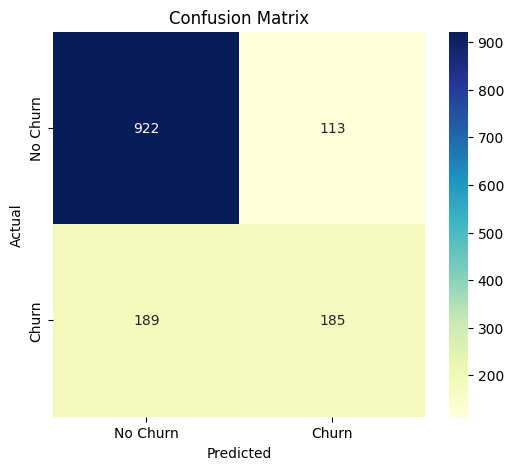

In [53]:
# ===============================
# Cell 21: Plot Confusion Matrix
# ===============================
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=["No Churn","Churn"],
            yticklabels=["No Churn","Churn"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

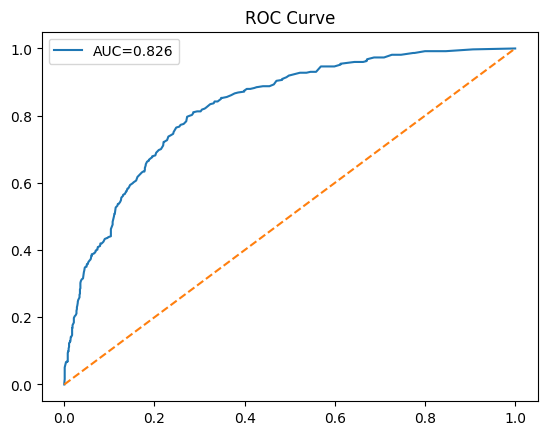

In [54]:
# ===============================
# Cell 22: ROC Curve
# ===============================

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

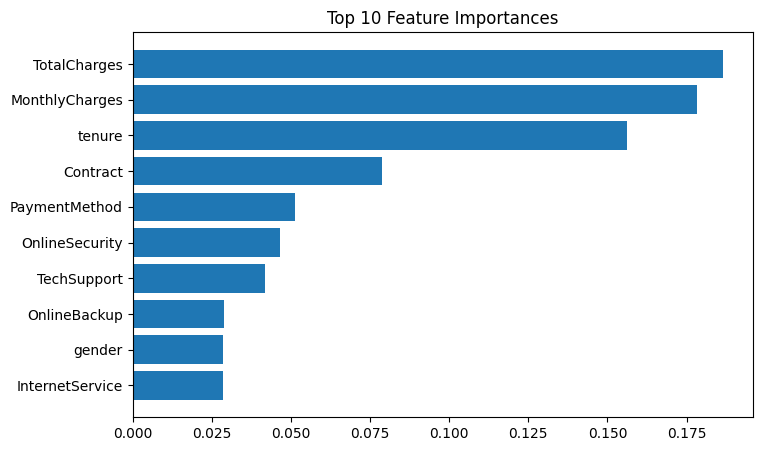

            Feature  Importance
18     TotalCharges    0.186567
17   MonthlyCharges    0.178139
4            tenure    0.156229
14         Contract    0.078746
16    PaymentMethod    0.051144
8    OnlineSecurity    0.046420
11      TechSupport    0.041666
9      OnlineBackup    0.028750
0            gender    0.028523
7   InternetService    0.028489


In [56]:
# ===============================
# Cell 23: Feature Importance
# ===============================

if best_name == "Random Forest":
    feature_names = X.drop(columns=["Churn"], errors="ignore").columns
    imp = best_model.feature_importances_

    feat_imp = pd.DataFrame({
        "Feature": feature_names,
        "Importance": imp
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(8,5))
    plt.barh(feat_imp["Feature"][:10], feat_imp["Importance"][:10])
    plt.gca().invert_yaxis()
    plt.title("Top 10 Feature Importances")
    plt.show()

    print(feat_imp.head(10))
else:
    print("Best model is not Random Forest, so no feature importance here.")

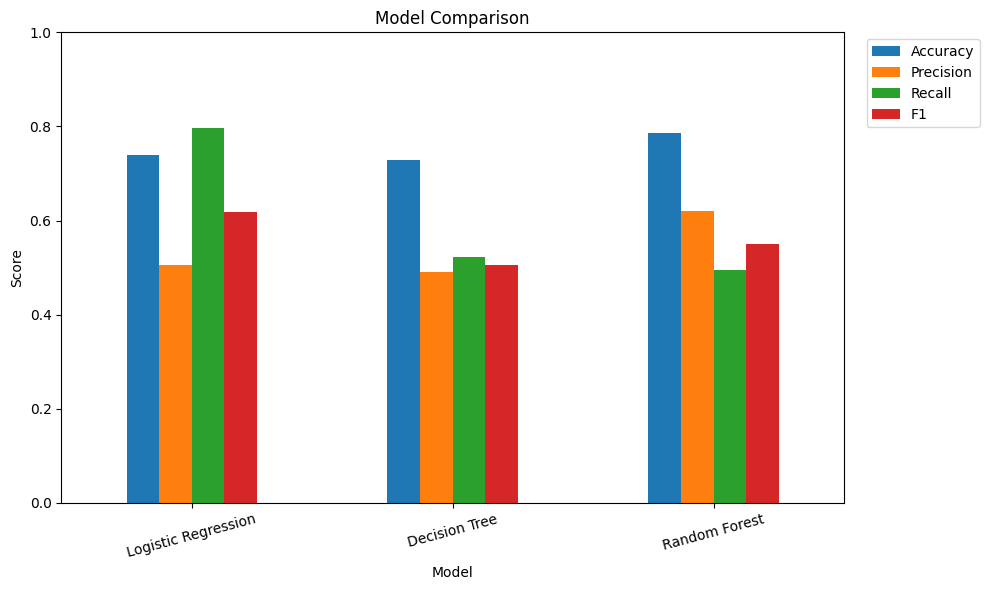

In [58]:
# ===============================
# Cell 24: Model Comparison Plot
# ===============================

ax = results_df.set_index("Model").plot(kind="bar", figsize=(10, 6))

ax.set_title("Model Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=15)

# legend outside
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

In [59]:
# ===============================
# Cell 25: Save Results
# ===============================

results_df.to_csv("results.csv", index=False)

In [60]:
# ===============================
# Cell 26: Save Clean Dataset
# ===============================

X["Churn"] = y
X.to_csv("cleaned_data.csv", index=False)

In [61]:
# ===============================
# Cell 27: Final Summary
# ===============================

print("Final Model:", best_name)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Final Model: Random Forest
Accuracy: 0.7856635911994322
F1 Score: 0.5505952380952381


In [62]:
# ===============================
# Cell 28: Save Model
# ===============================

import joblib
joblib.dump(best_model, "model.pkl")

['model.pkl']